**CUSTOMER SEGMENTATION USING K-MEANS**

**1. Import Required Libraries**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**2. Load Dataset**

In [13]:
df = pd.read_csv("Mall_Customers.csv")

# Display first 10 rows
df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


**3. Dataset Information**

In [14]:
# Display number of rows and columns
print("Dataset Shape:", df.shape)

# Display dataset information
df.info()

Dataset Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


**4. Select Features for Clustering**

In [15]:
# Select Annual Income and Spending Score
x = df.iloc[:, [3, 4]].values

print("Selected Features:")
print(x)

Selected Features:
[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [

**5. Find Optimal Number of Clusters**

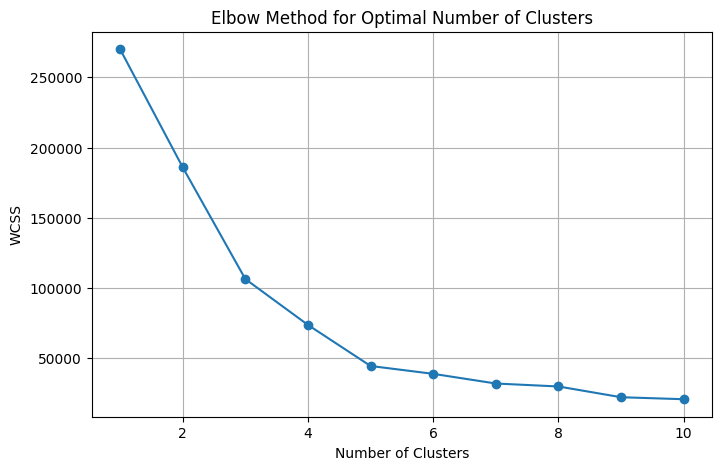

In [16]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=0
    )

    kmeans.fit(x)

    wcss.append(kmeans.inertia_)


# Plot WCSS values
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid()
plt.show()

**6. Apply K-Means Clustering**

In [17]:
kmeansmodel = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=0
)

# Predict cluster for each customer
y_kmeans = kmeansmodel.fit_predict(x)

print("Cluster Labels:")
print(y_kmeans)

Cluster Labels:
[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


**7. Visualize Customer Segments**

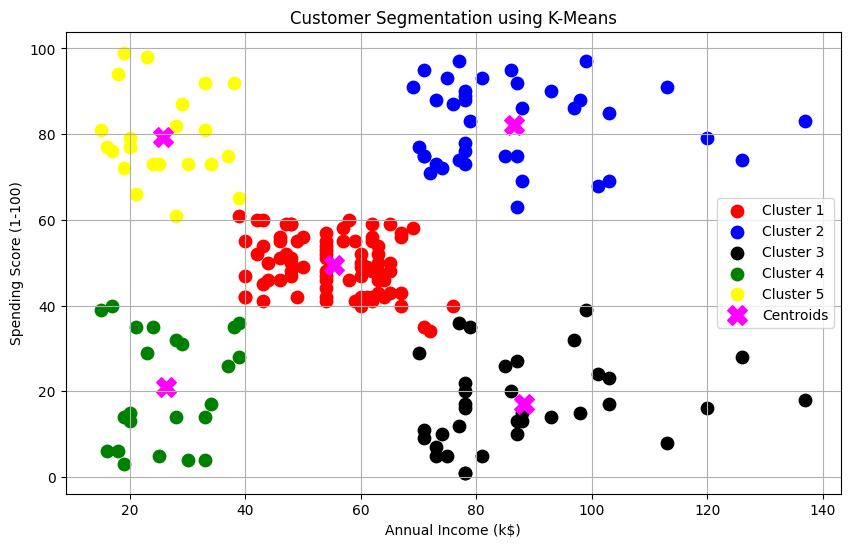

In [18]:
plt.figure(figsize=(10, 6))

plt.scatter(
    x[y_kmeans == 0, 0],
    x[y_kmeans == 0, 1],
    s=80,
    c="red",
    label="Cluster 1"
)

plt.scatter(
    x[y_kmeans == 1, 0],
    x[y_kmeans == 1, 1],
    s=80,
    c="blue",
    label="Cluster 2"
)

plt.scatter(
    x[y_kmeans == 2, 0],
    x[y_kmeans == 2, 1],
    s=80,
    c="black",
    label="Cluster 3"
)

plt.scatter(
    x[y_kmeans == 3, 0],
    x[y_kmeans == 3, 1],
    s=80,
    c="green",
    label="Cluster 4"
)

plt.scatter(
    x[y_kmeans == 4, 0],
    x[y_kmeans == 4, 1],
    s=80,
    c="yellow",
    label="Cluster 5"
)

# Plot cluster centroids
plt.scatter(
    kmeansmodel.cluster_centers_[:, 0],
    kmeansmodel.cluster_centers_[:, 1],
    s=200,
    c="magenta",
    marker="X",
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.legend()
plt.grid()

plt.show()

**8. Add Cluster Labels to Dataset**

In [19]:
df["Customer Cluster"] = y_kmeans

df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Customer Cluster
0,1,Male,19,15,39,3
1,2,Male,21,15,81,4
2,3,Female,20,16,6,3
3,4,Female,23,16,77,4
4,5,Female,31,17,40,3
5,6,Female,22,17,76,4
6,7,Female,35,18,6,3
7,8,Female,23,18,94,4
8,9,Male,64,19,3,3
9,10,Female,30,19,72,4


**9. Analyze Customer Segments**

In [20]:
cluster_summary = df.groupby("Customer Cluster")[
    ["Annual Income (k$)", "Spending Score (1-100)"]
].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100)
Customer Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,88.200000,17.114286
3,26.304348,20.913043
4,25.727273,79.363636
